## **Image Data Enrichment - Open CV for STL10**

The objective of this Python notebook is to compare 6 different image data enrichment techniques on the STL10 dataset, via OpenCV.

The methods used here are:

- No Processing
- Rotation
- Translation
- Scaling
- Noise
- Blur


### **Data Preparation**

This data below is to import the STL10 dataset after the cleaning operation of Standard Scaling via openCV, which has the best image cleaning effect after comparison.

In [1]:
!pip install tensorflow-datasets

import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.optimizers import Adam


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 4.0 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 4.0 MB/s  0:00:00 eta 0:00:01
  Created wheel for promise: filename=promise-2.3-py3-none-any.whl size=21581 sha256=f939ec2ca5535ad967f2107cf2cf83e411c81c191995086f43b5ea2388f804b6
  Stored in directory: /Users/baiqi/Library/Caches/pip/wheels/e1/e8/83/ddea66100678d139b14bc87692ece57c6a2a937956d2532608
Successfully built promise
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.8
    Uninstalling protobuf-4.25.8:
      Successfully uninstalled protobuf-4.25.8
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [tensorflow-datasets]nsorflow-datasets]


In [10]:
!pip install joblib

import os
from joblib import Parallel, delayed
import cv2

cv2.setUseOptimized(True)
cv2.setNumThreads(0)  


In [2]:
def load_tfds_dataset(datasetName):
    ds_train, ds_test = tfds.load(
        datasetName,
        split=["train", "test"],
        as_supervised=True
    )
    X_train = np.array([x.numpy() for x, y in ds_train])
    y_train = np.array([y.numpy() for x, y in ds_train])
    X_test  = np.array([x.numpy() for x, y in ds_test])
    y_test  = np.array([y.numpy() for x, y in ds_test])
    return X_train, y_train, X_test, y_test

trainImg, trainLabel, testImg, testLabel = load_tfds_dataset("stl10")
print(trainImg.shape, trainLabel.shape, testImg.shape, testLabel.shape)


2026-01-02 06:01:00.494571: W external/local_tsl/tsl/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata.google.internal".


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

...

Shuffling /Users/baiqi/tensorflow_datasets/stl10/1.0.0.incompleteS2B33B/stl10-unlabelled.tfrecord*...:   0%|  …

Dataset stl10 downloaded and prepared to /Users/baiqi/tensorflow_datasets/stl10/1.0.0. Subsequent calls will reuse this data.


2026-01-02 06:15:38.418874: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-02 06:15:38.705424: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-02 06:15:39.157547: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(5000, 96, 96, 3) (5000,) (8000, 96, 96, 3) (8000,)


2026-01-02 06:15:39.605875: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
### **Simple RNN Model**
def initRNN():
    model = Sequential([
        SimpleRNN(128, input_shape=(96, 96)),
        Dense(10, activation="softmax")
    ])
    model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    return model


In [4]:
trainLabelCategorical = to_categorical(trainLabel, 10)
testLabelCategorical  = to_categorical(testLabel, 10)


In [5]:
def standardScaling(img):
    if img.ndim == 3:  # RGB image
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    imgTemp = img.astype(np.float32)
    mean = np.mean(imgTemp)
    std = np.std(imgTemp) + 1e-8  

    return (imgTemp - mean) / std


### **Image Data Enrichment Methods**

In [6]:
def augment_cv2_stl(img, mode, rng):
    """
    img: (96,96) float32 
    mode: none|rotation|translation|scaling|noise|blur
    """
    H, W = img.shape

    # Method 1 - No Processing
    if mode == "none":
        out = img

    # Method 2 - Rotation
    elif mode == "rotation":
        angle = rng.uniform(-15, 15)
        M = cv2.getRotationMatrix2D((W/2, H/2), angle, 1.0)
        out = cv2.warpAffine(img, M, (W, H), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

    # Method 3 - Translation
    elif mode == "translation":
        tx = rng.uniform(-0.1, 0.1) * W
        ty = rng.uniform(-0.1, 0.1) * H
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        out = cv2.warpAffine(img, M, (W, H), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

    # Method 4 - Scaling
    elif mode == "scaling":
        scale = rng.uniform(0.85, 1.15)
        newW, newH = int(W * scale), int(H * scale)
        resized = cv2.resize(img, (newW, newH), interpolation=cv2.INTER_LINEAR)

        if scale >= 1.0:
            x0 = (newW - W) // 2
            y0 = (newH - H) // 2
            out = resized[y0:y0+H, x0:x0+W]
        else:
            pad_x = (W - newW) // 2
            pad_y = (H - newH) // 2
            out = cv2.copyMakeBorder(resized, pad_y, H-newH-pad_y, pad_x, W-newW-pad_x,
                                     borderType=cv2.BORDER_REFLECT_101)

    # Method 5 - Noise
    elif mode == "noise":
        sigma = rng.uniform(0.05, 0.15)
        noise = rng.normal(0, sigma, size=img.shape).astype(np.float32)
        out = img + noise

    # Method 6 - Blur
    elif mode == "blur":
        k = int(rng.choice([3, 5]))
        out = cv2.GaussianBlur(img, (k, k), sigmaX=0)

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return out.astype(np.float32)


### **Model Training and Evaluation**

In [11]:
def batch_augment_parallel(X, mode, seed=42, n_jobs=None):
    
    if mode == "none":
        return X

    if n_jobs is None:
        n_jobs = max(1, os.cpu_count() - 1)

    base_rng = np.random.default_rng(seed)
    seeds = base_rng.integers(0, 1_000_000_000, size=len(X))

    def _one(img, s):
        r = np.random.default_rng(int(s))
        return augment_cv2_stl(img, mode, r)

    out = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_one)(X[i], seeds[i]) for i in range(len(X))
    )
    return np.array(out, dtype=np.float32)


In [16]:
def comparisonModels(cleaningMethod, augMode="none", seed=42, epochs=5, batch_size=64):
    rng = np.random.default_rng(seed)

    
    trainImg2 = np.array([cleaningMethod(img) for img in trainImg], dtype=np.float32)
    testImg2  = np.array([cleaningMethod(img) for img in testImg], dtype=np.float32)

    
    trainImg2 = (trainImg2 / 255.0).reshape(-1, 96, 96).astype(np.float32)
    testImg2  = (testImg2  / 255.0).reshape(-1, 96, 96).astype(np.float32)

    
    if augMode != "none":
        trainImg2 = batch_augment_parallel(trainImg2, augMode, seed=seed, n_jobs=None)

    
    model = initRNN()
    model.fit(trainImg2, trainLabelCategorical, epochs=epochs, batch_size=batch_size, verbose=1)
    return model.evaluate(testImg2, testLabelCategorical, verbose=0)


In [17]:
modes = ["none", "rotation", "translation", "scaling", "noise", "blur"]

results = {}
for m in modes:
    loss, acc = comparisonModels(standardScaling, augMode=m)
    results[m] = (loss, acc)
    print(f"{m:12s} -> loss={loss:.4f}, acc={acc:.4f}")


Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.1291 - loss: 2.2869
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.1458 - loss: 2.2298
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.1676 - loss: 2.1512
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.1912 - loss: 2.1131
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.1722 - loss: 2.1749
none         -> loss=2.1625, acc=0.1511
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.1102 - loss: 2.3189
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.1607 - loss: 2.2358
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.1605 - loss: 2.1817
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.1593 - loss: 2.1815
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1031s 13s/step - accuracy: 0.1648 - loss: 2.1682
rotation     -> loss=2.1393, acc=0.1751
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1146s 15s/step - accuracy: 0.1189 - loss:

### **Comparison**

In [18]:
import pandas as pd

results_df = pd.DataFrame(
    [{"Augmentation Method": k, "Test Loss": v[0], "Test Accuracy": v[1]} for k, v in results.items()]
)

results_df = results_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
results_df


,Augmentation Method,Test Loss,Test Accuracy
0,scaling,2.106633,0.205375
1,blur,2.146670,0.180375
2,rotation,2.139330,0.175125
3,translation,2.178481,0.169750
4,none,2.162543,0.151125
5,noise,2.217695,0.143000


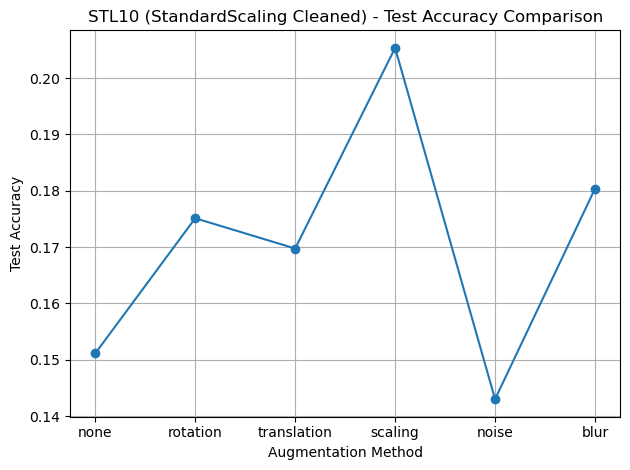

In [19]:
import matplotlib.pyplot as plt

order = ["none", "rotation", "translation", "scaling", "noise", "blur"]
results_df_plot = results_df.copy()
results_df_plot["Augmentation Method"] = pd.Categorical(
    results_df_plot["Augmentation Method"], categories=order, ordered=True
)
results_df_plot = results_df_plot.sort_values("Augmentation Method")

plt.figure()
plt.plot(results_df_plot["Augmentation Method"], results_df_plot["Test Accuracy"], marker="o")
plt.xlabel("Augmentation Method")
plt.ylabel("Test Accuracy")
plt.title("STL10 (StandardScaling Cleaned) - Test Accuracy Comparison")
plt.grid(True)
plt.tight_layout()
plt.show()


- The result of line chart indicates that the image enrichment method with the worst effect is the Noise, while the best one is the Scaler.
- In addition, the Translation, Rotation and Blur have similar performances, with slight benefit.
- Due to the inherent mismatch between RNN model and high-resolution natural image data from STL10 dataset, all experiments resulted in relatively low classification accuracy.